# Objectif du notebook 

Date de création : 22/01/2026

Première analyse des données Fiberscope Groix pour la méthode RTF-MFP

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as sp 
from datetime import datetime, timedelta

# import gc

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, color 

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

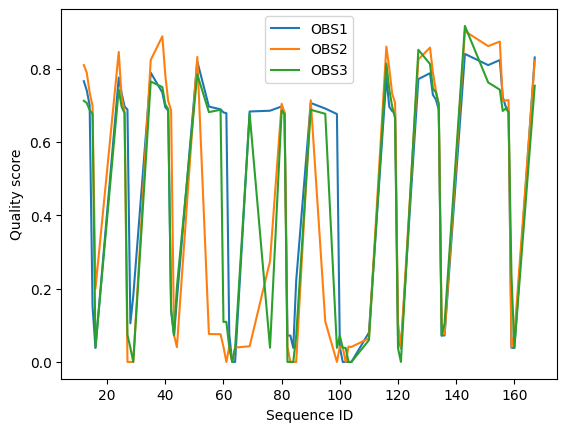

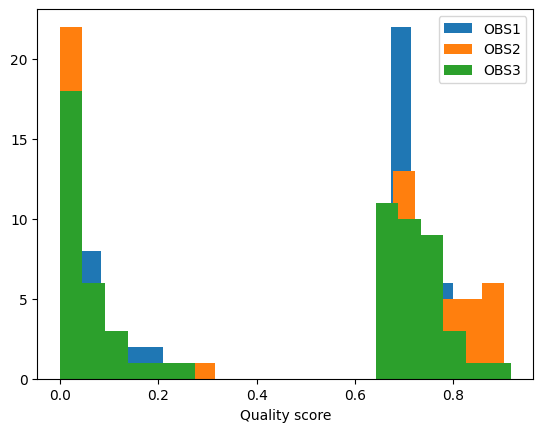

In [5]:
seq_ids = df_arr["Sequence_id"].unique()

# Plot f_score for each OBS

plt.figure()
for obs_id in [1, 2, 3]:
    col_name = f"f_score OBS{obs_id}"
    f_score = df_arr.groupby("Sequence_id")[col_name].mean()        # Mean over constant array = val (kick trick to compute it)

    # Plot f_score 
    plt.plot(seq_ids, f_score, label=f"OBS{obs_id}")

plt.xlabel("Sequence ID")
plt.ylabel("Quality score")
plt.legend()

plt.figure()
for obs_id in [1, 2, 3]:
    col_name = f"f_score OBS{obs_id}"
    f_score = df_arr.groupby("Sequence_id")[
        col_name
    ].mean()  # Mean over constant array = val (kick trick to compute it)

    # Plot f_score
    plt.hist(f_score, bins=20, label=f"OBS{obs_id}")

plt.xlabel("Quality score")
plt.legend()
# plt.ylabel("Quality score")

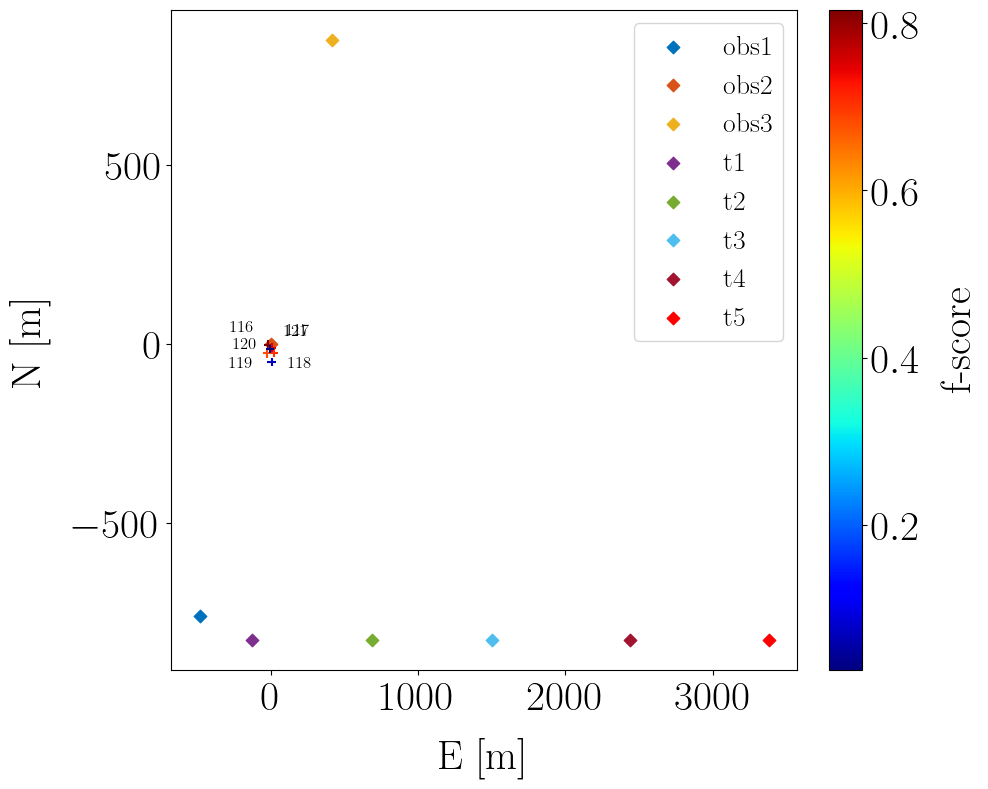

In [18]:
# Tracer des positions d'émission et des positions des OBS sur une carte
df_arr_plot = df_arr.loc[df_arr["Point"] == "2S"]
sel_sequence_id_to_analyse = df_arr_plot["Sequence_id"].unique()
# sel_sequence_id_to_analyse = [117, 121]


seq_e_pos = []
seq_n_pos = []
seq_mean_fscore = []

# Plot
plt.figure(figsize=(10, 8))
for i, seq_id in enumerate(sel_sequence_id_to_analyse):
    df_sequence = df_arr.loc[df_arr["Sequence_id"] == seq_id]

    mean_f_score = (
        df_sequence["f_score OBS1"].iloc[0]
        + df_sequence["f_score OBS2"].iloc[0]
        + df_sequence["f_score OBS3"].iloc[0]
    ) / 3
    seq_mean_fscore.append(mean_f_score)
    seq_e_pos.append(df_sequence["Emission interpolated E GPS"].iloc[0])
    seq_n_pos.append(df_sequence["Emission interpolated N GPS"].iloc[0])


    # plt.scatter(
    #     df_sequence["Emission interpolated E GPS"].iloc[0],
    #     df_sequence["Emission interpolated N GPS"].iloc[0],
    #     marker="+",
    #     color="k",
    #     # "s",
    #     # label="Sequence emission pos",
    # )

    # Annotate with sequence id
    # Alternate the position of the labels to avoid overlap
    ha = "right" if i % 4 in [0, 3] else "left"
    x_offset = -10 if i % 4 in [0, 3] else 10
    y_offset = 10 if i % 4 in [0, 1] else -10
    plt.annotate(
        seq_id,
        (
            df_sequence["Emission interpolated E GPS"].iloc[0],
            df_sequence["Emission interpolated N GPS"].iloc[0],
        ),
        textcoords="offset points",
        xytext=(x_offset, y_offset),
        ha=ha,
        fontsize=12,
        # color=mean_f_score,
    )

# Plot emission pos
im = plt.scatter(x=seq_e_pos, y=seq_n_pos, marker="+", c=seq_mean_fscore, cmap="jet")
plt.colorbar(label="f-score")
plt.xlabel("E [m]")
plt.ylabel("N [m]")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for ik, k in enumerate(keys):
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=0,
        color=color(ik),
        s=40,
    )


plt.legend()

In [7]:
for i, seq_id in enumerate(sel_sequence_id_to_analyse): 
    print(f'ID {seq_id} -> {seq_mean_fscore[i]}')
# print(sel_sequence_id_to_analyse)
# print(seq_mean_fscore)

ID 127 -> 0.8161499234716453
ID 131 -> 0.8192487352510341
ID 132 -> 0.7546386511238999
ID 133 -> 0.7311794392876036
ID 134 -> 0.6978671989630794
ID 135 -> 0.08330113852545924
ID 136 -> 0.08406060568951396
ID 143 -> 0.8863708591390607


# Étude de la séquence 117 

In [8]:
# seq_id = [117, 127, 131, 132, 133]  # , 134, 135, 136, 143]
seq_id = [117, 127, 151]  # , 134, 135, 136, 143]
seq_id = [116, 117, 127, 143, 151, 155]  # , 134, 135, 136, 143]

df_seq = df_arr.loc[df_arr["Sequence_id"].isin(seq_id)]
# df_seq.head(25)

In [9]:
# Load wav data from netcdf
nc_fpath = os.path.join(data_folder, "wav.nc")
ds_wav = xr.open_dataset(nc_fpath)

datetime_fmt = ds_wav.attrs["datetime_format"]
fs = ds_wav.attrs[f"fs_obs{1}"]
ts = 1/fs

In [10]:
# Select window size to compute RTF 
tau_ir_sim = 0.01       # Estimated impulse response duration (-30dB) on profile p1
tau_rtf_analysis = 10 * tau_ir_sim  # To ensure we include the entire response 

# Number of samples corresponding to the assumed impulse response duration
n_rtf_analysis = int(
    tau_rtf_analysis * fs
)  
# Get closer power of 2
nperseg = 2 ** int(
    np.log2(n_rtf_analysis) + 1
)  # Number of sample per snapshot to use = closest power of two
alpha_overlap = 0.5
noverlap = int(nperseg * alpha_overlap)

print(f"nperseg = {nperseg}, noverlap = {noverlap}")

nperseg = 256, noverlap = 128


In [11]:
from real_data_analysis.deconvolution_utils import crosscorr_deconvolution

In [12]:
# # Create the source pulse signal
# n_hydro = xr_data.sizes["h_index"]
# t_ir = tau_rtf_analysis                 # TODO check this 
# n_em = df_seq["Nrepeat"].iloc[0]        # TODO : we might need to change that to account for non detected arrivals ? 
# t_pulse = df_seq["Duration (s)"].iloc[0]
# t_interp_pulse = df_seq["Trepeat (s)"].iloc[0]
# f0 = df_seq["Frequency min (Hz)"].iloc[0]
# f1 = df_seq["Frequency max (Hz)"].iloc[0]

# # Reference chirp
# t = xr_data.signal.sel(time=slice(0, t_pulse)).time.values
# x = sp.chirp(t, f0=f0, f1=f1, t1=t_pulse, method="linear")

# # Time to first arrival
# t0 = xr_data.t0

# init_ri_hat = True
# # Loop over each hydrophone to process
# i_hydro = 0
# for hydro_idx in xr_data.h_index.values:

#     # Process each emission
#     for i_em in range(n_em):
#         # Extract the emission
#         y = xr_data.signal.sel(
#             time=slice(
#                 t0 + i_em * t_interp_pulse - ts/2, t0 + i_em * t_interp_pulse + t_pulse + t_ir + ts/2
#             ),
#             h_index=hydro_idx,
#         )

#         if init_ri_hat:
#             ri_hat = np.zeros((n_hydro, n_em, y.sizes["time"]))
#             time = y.time.values
#             init_ri_hat = False

#         # Estimate the impulse response
#         h_hat = crosscorr_deconvolution(x=x, y=y.values)
#         ri_hat[i_hydro, i_em, :] = h_hat


#     i_hydro += 1

# # Take the mean impulse response over all sweeps analysed
# ri_hat_mean = np.mean(ri_hat, axis=1)

# xr_data["t_ir"] = time - t0
# xr_data["ri_hat"] = (
#     ["h_index", "t_ir"],
#     ri_hat_mean,
# )

# # Derive the corresponding frequency response
# # nstft = self.nperseg
# nstft = time.size
# tf_hat_mean = np.fft.rfft(ri_hat_mean, n=nstft, axis=1)
# f_ir = np.fft.rfftfreq(nstft, d=ts)
# xr_data["f_ir"] = f_ir

# # Store amplitude and phase in two separate variables to avoid issues with complex in netcdf
# xr_data["tf_hat_amp"] = (
#     ["h_index", "f_ir"],
#     np.abs(tf_hat_mean),
# )
# xr_data["tf_hat_phase"] = (
#     ["h_index", "f_ir"],
#     np.angle(tf_hat_mean),
# )

# # # Save results
# # xr_data.to_netcdf(
# #     os.path.join(xr_data.root_data, f"{xr_data.recording_name}.nc")
# # )
# # xr_data.close()
# # del xr_data

In [13]:
# # Plot impulse response
# plt.figure()
# xr_data.ri_hat.plot(hue="h_index")
# plt.xlim(0, 0.2)

# # Plot transfer functions
# plt.figure()
# xr_data["tf_hat_amp"].plot(hue="h_index")



In [14]:
# Limit the number of signal to process within the sequence to analyse the influence of the number of singals 
n_em_to_process = 1
idx_to_keep = np.concatenate([[k + i*10 for k in range(n_em_to_process)] for i in range(df_seq["Sequence_id"].unique().size)])
df_seq = df_seq.iloc[idx_to_keep]

In [15]:
from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import FiberscopeManager, BandFilter
bandfilter = BandFilter(
    order=6, 
    lowcut=100,
    highcut=900,
)

h_index_ref = 1 # -> OBS 3 has the higher snr 
# root_rtf_data = os.path.join(data_folder, "rtf")
plot_feature = True
fsm = FiberscopeManager(
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    plot_feature=plot_feature,
    bandfilter=bandfilter,
    tau_ir=3
)

fsm.process_static_analysis(
    df_arrivals=df_seq,
    set_stft_props=True,
    rtf_estimator="cs-evd",
    verbose=False,
)

Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%

In [16]:
print(fsm.nperseg)

8192
